In [1]:
%cd ..

/Users/danorel/Workspace/Education/University/NYU/Research/xeda


In [2]:
import chromadb
import copy
import json
import typing as t
import uuid
import pathlib

from chromadb.utils import embedding_functions
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv())

from constants import (
    AWS_ACCESS_KEY_ID,
    AWS_SECRET_ACCESS_KEY,
    AWS_S3_ENDPOINT_URL,
    AWS_S3_REGION_NAME,
    AWS_S3_BUCKET_NAME,
    AWS_S3_USE_SSL,
    OPENAI_API_KEY,
    VECTOR_STORE_COLLECTION,
    VECTOR_STORE_HOST,
    VECTOR_STORE_PORT
)
from typings.pipeline import Pipeline
from pipeline.solid.pipeline_sampler import next_pipeline_iter
from utils.s3 import pull_keras_model

2024-04-05 15:46:13.946364: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def node_to_encoding(node):
    annotation = node["annotation"]
    node_encoding = []
    for k, v in annotation.items():
        if isinstance(v, dict):
            for key in v:
                node_encoding.append(f"{k}_{key} = {v[key]}")
        else:
            node_encoding.append(f"{k} = {v}")
    return ', '.join(node_encoding)


def pipeline_to_splits(pipeline: Pipeline) -> t.List[Pipeline]:
    splits = []
    pipeline_encoding = []
    for node in reversed(pipeline):
        node_encoding = node_to_encoding(node)
        pipeline_encoding.append(node_encoding)
        splits.append(copy.deepcopy(pipeline_encoding))
    return splits


def pipeline_to_embedding(pipeline: Pipeline):
    pipeline_splits = pipeline_to_splits(pipeline)
    pipeline_payload = (
        [str(uuid.uuid4()) for _ in range(len(pipeline_splits))],
        [json.dumps(copy.deepcopy(pipeline)) for _ in range(len(pipeline_splits))],
        [';'.join(pipeline_split) for pipeline_split in pipeline_splits]
    )
    return pipeline_payload

In [4]:
pretrained_embeddings = embedding_functions.OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name="text-embedding-ada-002"
)

vector_store = chromadb.HttpClient(
    host=VECTOR_STORE_HOST, 
    port=VECTOR_STORE_PORT
)

In [5]:
vector_collection = vector_store.get_collection(VECTOR_STORE_COLLECTION)

In [6]:
root_dir = pathlib.Path.cwd()

In [7]:
annotated_dir, raw_dir = (
    root_dir / "data" / "eda4sum" / "annotated",
    root_dir / "data" / "eda4sum" / "raw"
)

In [8]:
annotated_pipelines = []
for annotated_file in annotated_dir.glob('*.json'):
    with annotated_file.open('r') as f:
        annotated_pipelines.append(json.load(f))

In [9]:
for annotated_pipeline in annotated_pipelines:
    (
        pipeline_ids,
        pipeline_documents,
        pipeline_sentences
    ) = pipeline_to_embedding(annotated_pipeline)
    vector_collection.add(
        ids=pipeline_ids,
        documents=pipeline_documents,
        embeddings=pretrained_embeddings(pipeline_sentences),
    )

In [10]:
pipeline_collection = vector_collection.get()

In [11]:
pipeline_collection.keys()

dict_keys(['ids', 'embeddings', 'metadatas', 'documents', 'data', 'uris'])

In [12]:
import s3fs

from dagster import EnvVar
from pipeline.resources import S3FSResource

fs = s3fs.S3FileSystem(
    key=AWS_ACCESS_KEY_ID,
    secret=AWS_SECRET_ACCESS_KEY,
    endpoint_url=AWS_S3_ENDPOINT_URL,
    use_ssl=AWS_S3_USE_SSL,
    client_kwargs={"region_name": AWS_S3_REGION_NAME},
)

# TODO: Change policy to universal / generalized one from the EDA UI
POLICY_NAME = "policy_0f2049f5-3807-4db4-9707-ea08a6d35383_concentrated"

In [13]:
!pip install --quiet scikit-learn

In [14]:
import random
import pandas as pd
import numpy as np

from tqdm import tqdm

from pipeline.solid.utils.model_manager import ModelManager
from pipeline.solid.utils.pipelines.pipeline_precalculated_sets import PipelineWithPrecalculatedSets
from sklearn.metrics.pairwise import cosine_similarity
from typings.pipeline import RequestData

def select_attributes(pipeline):
    return f"{[node['operator'] for node in pipeline]}"

def explore_pipeline(partial_pipeline: Pipeline, database_pipeline_cache, k: int):
    # This is a stub to simulate pipeline exploration.
    # In a real scenario, this would involve applying transformations or decisions based on an RL model.
    model_manager = ModelManager(database_pipeline_cache["galaxies"], models = {
        "set": pull_keras_model(
            s3fs=fs,
            bucket_name=AWS_S3_BUCKET_NAME,
            policy_name=POLICY_NAME,
            model_name="set_actor",
        ),
        "operation": pull_keras_model(
            s3fs=fs,
            bucket_name=AWS_S3_BUCKET_NAME,
            policy_name=POLICY_NAME,
            model_name="operation_actor",
        ),
        "set_op_counters": None,
    })

    partial_latest_node = partial_pipeline[-1]
    partial_latest_request_data = partial_latest_node.get("requestData")
    
    terminal_request_data = RequestData(**partial_latest_request_data)
    terminal_pipeline = partial_pipeline.copy()
    
    for i in range(len(partial_pipeline), len(partial_pipeline) + k):
        try:
            terminal_node, terminal_request_data = next_pipeline_iter(
                database_pipeline_cache,
                model_manager,
                terminal_request_data
            )
            terminal_pipeline.append(terminal_node)
        except ValueError:
            print(f"Unexpectedly exited from pipeline generation on step {i}. Saving pipeline as it is...")
            break
    
    return terminal_pipeline

def make_experiment(pipeline_index: int, database_pipeline_cache, type_of_similarity: str, k: int, verbose: bool = False):

    ids  = pipeline_collection['ids']
    docs = pipeline_collection['documents']

    partial_pipeline_id   = ids[pipeline_index]
    partial_pipeline = json.loads(docs[pipeline_index])
    
    rest_pipeline_ids = ids[:pipeline_index] + ids[pipeline_index+1:]
    rest_pipelines = [json.loads(doc) for doc in docs[:pipeline_index] + docs[pipeline_index+1:]]
    
    (
        partial_pipeline_ids,
        partial_pipeline_documents,
        partial_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    
    partial_annotation_embedding = pretrained_embeddings(partial_pipeline_sentences)
    partial_response = vector_collection.query(
        query_embeddings=partial_annotation_embedding,
        n_results=len(rest_pipeline_ids),
        include=["distances", "documents"]
    )
    
    terminal_pipeline = explore_pipeline(partial_pipeline, database_pipeline_cache, k=k)
    (
        terminal_pipeline_ids,
        terminal_pipeline_documents,
        terminal_pipeline_sentences
    ) = pipeline_to_embedding(partial_pipeline)
    terminal_annotation_embedding = pretrained_embeddings(terminal_pipeline_sentences)
    
    if verbose:
        print(f"Terminal pipeline: {select_attributes(partial_pipeline)}\n")

    partial_explanation_pipelines = partial_response['documents'][0]

    min_explanation_pipeline, max_explanation_pipeline = (
        json.loads(partial_explanation_pipelines[0]),
        json.loads(partial_explanation_pipelines[-1])
    )

    if verbose:
        print(f"Min pipeline: {min_explanation_distance}%, {select_attributes(min_explanation_pipeline)}")
        print(f"Max pipeline: {max_explanation_distance}%, {select_attributes(max_explanation_pipeline)}\n")

    (
        min_pipeline_ids,
        min_pipeline_documents,
        min_pipeline_sentences
    ) = pipeline_to_embedding(min_explanation_pipeline)
    min_annotation_embedding = pretrained_embeddings(min_pipeline_sentences)

    (
        max_pipeline_ids,
        max_pipeline_documents,
        max_pipeline_sentences
    ) = pipeline_to_embedding(max_explanation_pipeline)
    max_annotation_embedding = pretrained_embeddings(max_pipeline_sentences)

    terminal_annotation_embedding = np.array(terminal_annotation_embedding).mean(axis=0)
    min_annotation_embedding = np.array(min_annotation_embedding).mean(axis=0)
    max_annotation_embedding = np.array(max_annotation_embedding).mean(axis=0)
    
    if type_of_similarity == 'cosine':
        min_to_terminal_similarity = np.dot(terminal_annotation_embedding, min_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(min_annotation_embedding))
        max_to_terminal_similarity = np.dot(terminal_annotation_embedding, max_annotation_embedding)/(np.linalg.norm(terminal_annotation_embedding)*np.linalg.norm(max_annotation_embedding))
    elif type_of_similarity == 'euclidian':
        min_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - min_annotation_embedding)
        max_to_terminal_similarity = np.linalg.norm(terminal_annotation_embedding - max_annotation_embedding)
    elif type_of_similarity == 'manhattan':
        min_to_terminal_similarity = np.abs(terminal_annotation_embedding - min_annotation_embedding).sum()
        max_to_terminal_similarity = np.abs(terminal_annotation_embedding - max_annotation_embedding).sum()
    else:
        raise NotImplementedError("Unknown type of similarity")
        
    return {
        "partial_pipeline_id": partial_pipeline_id,
        "min_to_terminal_similarity": min_to_terminal_similarity,
        "max_to_terminal_similarity": max_to_terminal_similarity,
    }

def run_experiments(n: int = 1000, types_of_similarity: list = ['cosine'], exploration_steps: tuple = (3, 6)):
    measurements = pd.DataFrame()
    used_pipeline_ids = set()

    database_pipeline_cache = {}
    database_pipeline_cache["galaxies"] = PipelineWithPrecalculatedSets(
        "sdss",
        ["galaxies"],
        discrete_categories_count=10,
        min_set_size=10,
        exploration_columns=[
            "galaxies.u",
            "galaxies.g",
            "galaxies.r",
            "galaxies.i",
            "galaxies.z",
            "galaxies.petroRad_r",
            "galaxies.redshift",
        ],
        id_column="galaxies.objID",
    )

    for experiment in tqdm(range(n)):

        print(f"Starting '{experiment + 1}' experiment")

        for k in range(*exploration_steps):

            print(f"Starting a measurement with '{k}' exploration steps")

            for type_of_similarity in types_of_similarity:

                print(f"Starting a measurement with '{type_of_similarity}' type of similarity")
    
                trial = 0
                target_pipeline_index, target_pipeline_id = None, None
                while (target_pipeline_id not in used_pipeline_ids):
                    trial += 1
                    print(f"Making {trial} trial to sample partial pipeline within not seen pipelines")
                    (
                        target_pipeline_index,
                        target_pipeline_id
                    ) = random.sample(list(enumerate(pipeline_collection['ids'])), k=1)[0]
                    if target_pipeline_id is not None:
                        used_pipeline_ids.add(target_pipeline_id)
                
                measurements = pd.concat([
                    measurements,
                    pd.DataFrame([{
                        "experiment": experiment + 1,
                        "k": k,
                        "type_of_similarity": type_of_similarity,
                        **make_experiment(
                            target_pipeline_index, 
                            database_pipeline_cache, 
                            type_of_similarity,
                            k, 
                            verbose=False
                        )
                    }])
                ])
        
                print(f"Recored a measurement for {experiment + 1}-th sample {target_pipeline_id}")

    return measurements

In [15]:
experiments_df = run_experiments(
    n=3,
    types_of_similarity=['cosine', 'euclidian'],
    exploration_steps=(3, 5),
)

  0%|                                                                                                                    | 0/3 [00:00<?, ?it/s]

Starting '1' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'cosine' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 384ms/step
[0.06291454 0.06032396 0.05923535 0.15096668 0.11207605 0.19907398
 0.03183361 0.05444521 0.15011053 0.11902009]
[0.14121705409294644, 0.13540227326859852, 0.1329587980863204, 0.3388576007344763, 0.2515642738176583, 0.0, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 466ms/step
[0.03824119 0.05086677 0.04511657 0.04638046 0.04175233 0.17357454
 0.07962775 0.07801259 0.01628212 0.06891202 0.0747974  0.11602237
 0.05022685 0.06824071 0.02343599 0.02851032]
[0.0720660825094438, 0.09585915630215124, 0.0, 0.0, 0.0, 0.0, 0.15005965269484986, 0.0, 0.0, 0.12986569036652518, 0.1409567794401083, 0.2186458328980635, 0.09465322950802633, 0.0, 0.044165464941311273, 0.053728111339520546]
by_superset
1/1 [==============================] - 

 33%|███████████████████████████████████▋                                                                       | 1/3 [08:15<16:31, 495.77s/it]

Recored a measurement for 1-th sample 30264f61-d5ee-46be-a2f5-daad61b4f378
Starting '2' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'cosine' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 291ms/step
[0.07370613 0.02808681 0.04583098 0.07799113 0.07902113 0.09158801
 0.02331017 0.04693351 0.45166922 0.0818629 ]
[0.17568556521447223, 0.06694757570385058, 0.10924250036546815, 0.18589925893378856, 0.18835437174181507, 0.21830872800389906, 0.05556200003670637, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 335ms/step
[0.02812957 0.04459478 0.04050616 0.03896572 0.04153155 0.15167897
 0.08559809 0.10503701 0.01487703 0.05226964 0.06661787 0.17079813
 0.04896804 0.06483023 0.02141517 0.02418204]
[0.04787529272306944, 0.07589835319550393, 0.0, 0.06631794118644109, 0.0, 0.25815093415711843, 0.0, 0.0, 0.025320051307333134, 0.08896063754766555, 0.0, 0.2906909119

  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/pipeline_sampler/operators/by_neighbors.py", line 34, in by_neighbors
    prediction_result = model_manager.get_prediction(
  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/utils/model_manager.py", line 50, in get_prediction
    np.array(new_set_states).reshape(


...

Recored a measurement for 2-th sample c11c4095-84b3-4ac7-aff6-2ecb9826910a
Starting '3' experiment
Starting a measurement with '3' exploration steps
Starting a measurement with 'cosine' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 338ms/step
[0.06409882 0.14747341 0.08064068 0.0659435  0.23150369 0.04980345
 0.09471154 0.06887679 0.0498749  0.14707322]
[0.10023842631825494, 0.2306205115889374, 0.12610676868909612, 0.10312315832549503, 0.36202796696875833, 0.07788316810945826, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 322ms/step
[0.06213957 0.07149175 0.07137859 0.05060423 0.05701182 0.10087465
 0.06890807 0.05821244 0.04529922 0.05490356 0.0714727  0.06498797
 0.05708172 0.0604266  0.05165507 0.05355204]
[0.11345321119696512, 0.13052824115304834, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.10024184539819823, 0.13049346381299032, 0.11865376615610515, 0.10421868461254602, 0.11032569654877682,

  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/pipeline_sampler/operators/by_neighbors.py", line 34, in by_neighbors
    prediction_result = model_manager.get_prediction(
  File "/Users/danorel/Workspace/Education/University/NYU/Research/xeda/pipeline/solid/utils/model_manager.py", line 50, in get_prediction
    np.array(new_set_states).reshape(


Recored a measurement for 3-th sample 5a269ba1-f7b0-4336-8c7f-6d9c617927ce
Starting a measurement with '4' exploration steps
Starting a measurement with 'cosine' type of similarity
Making 1 trial to sample partial pipeline within not seen pipelines
1/1 [==============================] - 0s 287ms/step
[0.04778884 0.18835042 0.03926666 0.03194501 0.24267509 0.03166584
 0.14211279 0.07215569 0.0650906  0.13894905]
[0.08215490450036211, 0.32379758883325066, 0.06750422859633538, 0.054917403575152755, 0.41718838891980214, 0.054437485575096964, 0.0, 0.0, 0.0, 0.0]
1/1 [==============================] - 0s 318ms/step
[0.06678503 0.05498178 0.06066067 0.04477524 0.06951377 0.14302337
 0.07774604 0.04033106 0.02390141 0.07043206 0.09617204 0.08944929
 0.04681322 0.04791785 0.0260488  0.04144838]
[0.12047867613200057, 0.09918588137444441, 0.0, 0.0, 0.0, 0.0, 0.0, 0.07275632263735411, 0.0, 0.12705783300597046, 0.17349216888118588, 0.1613644916679255, 0.08444997985661887, 0.08644271706056392, 0.0, 

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [24:24<00:00, 488.31s/it]

Recored a measurement for 3-th sample e30c9043-573e-47ba-ba33-62db65e92dd6


### Visualizations

In [16]:
!pip install --quiet matplotlib seaborn

In [129]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

In [138]:
visualization_df = experiments_df.copy()

cosine_index = visualization_df['type_of_similarity'] == 'cosine'

visualization_df.loc[cosine_index, 'min_to_terminal_similarity'] = np.arccos(visualization_df.loc[cosine_index]['min_to_terminal_similarity']).fillna(0).map(lambda acos: (math.pi - acos) * 100 / math.pi)
visualization_df.loc[cosine_index, 'max_to_terminal_similarity'] = np.arccos(visualization_df.loc[cosine_index]['max_to_terminal_similarity']).fillna(0).map(lambda acos: (math.pi - acos) * 100 / math.pi)

/Users/danorel/miniconda3/envs/xeda_3.8.15/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [139]:
visualization_df

,experiment,k,type_of_similarity,partial_pipeline_id,min_to_terminal_similarity,max_to_terminal_similarity
0,1,3,cosine,8ce230c1-10d3-406f-8ad3-841464a4b620,99.976097,91.078792
0,1,3,euclidian,2e94a5e9-d8c1-44b5-a040-b2cddb019c11,0.001046,0.275894
0,1,4,cosine,a608fc03-8836-4bdf-bc21-0805357899c3,100.000000,89.949180
0,1,4,euclidian,30264f61-d5ee-46be-a2f5-daad61b4f378,0.007937,0.294885
0,2,3,cosine,83dc90e4-216e-425a-bd76-d81b4b3d2ac5,100.000000,90.628474
0,2,3,euclidian,3d182f0d-7da5-441d-95ce-394b07f09ded,0.000000,0.275140
0,2,4,cosine,3c4d2a8f-e970-4dae-b22f-93e42e327787,99.977384,90.628474
0,2,4,euclidian,c11c4095-84b3-4ac7-aff6-2ecb9826910a,0.000000,0.294038
0,3,3,cosine,a608fc03-8836-4bdf-bc21-0805357899c3,99.913112,89.949190
0,3,3,euclidian,5a269ba1-f7b0-4336-8c7f-6d9c617927ce,0.001764,0.288542


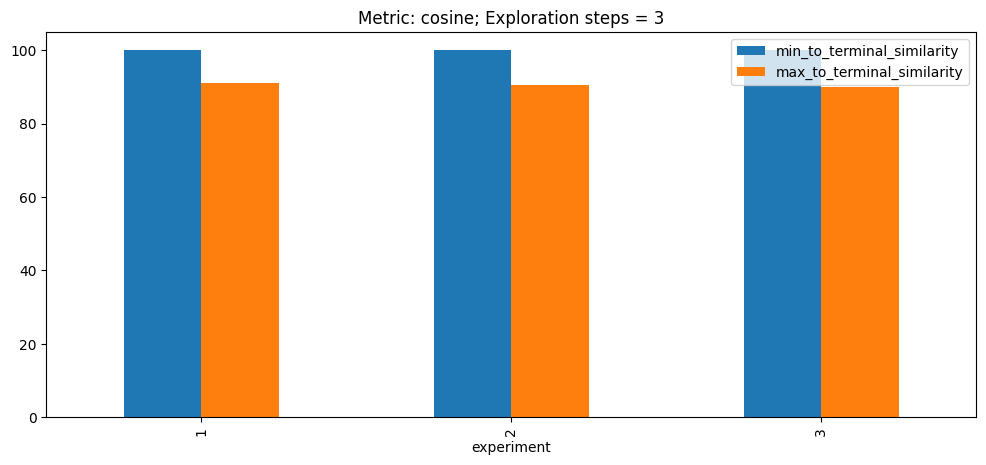

In [140]:
cosine_3k_df = visualization_df.loc[(visualization_df['type_of_similarity'] == 'cosine') & (visualization_df['k'] == 3)][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = cosine_3k_df.plot(
    kind='bar',
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: cosine; Exploration steps = 3',
    figsize=(12, 5)
)
plt.show()

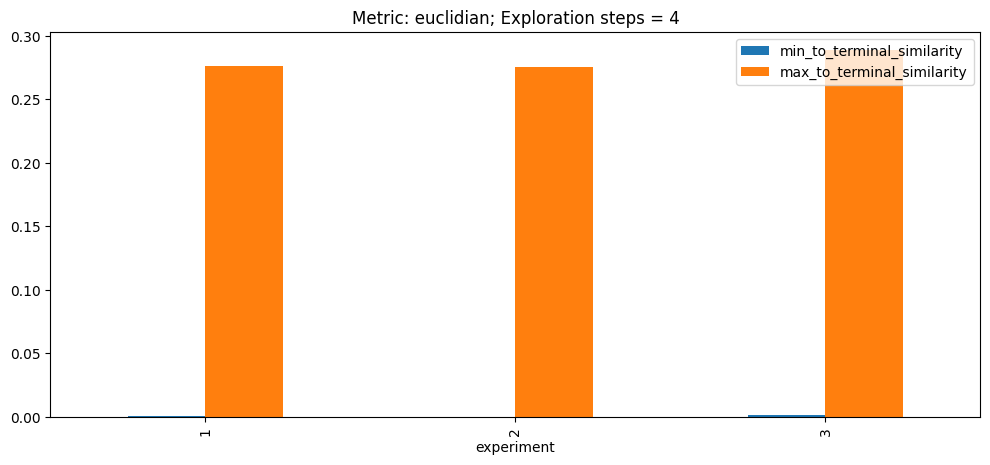

In [141]:
euclidian_3k_df = visualization_df.loc[
    (visualization_df['type_of_similarity'] == 'euclidian') & 
    (visualization_df['k'] == 3)
][['experiment', 'min_to_terminal_similarity', 'max_to_terminal_similarity']]

plot = euclidian_3k_df.plot(
    kind='bar', 
    x='experiment', 
    y=['min_to_terminal_similarity', 'max_to_terminal_similarity'],
    title='Metric: euclidian; Exploration steps = 4',
    figsize=(12, 5)
)
plt.show()

In [142]:
euclidian_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'euclidian']

euclidian_experiments_success_condition = (euclidian_df['max_to_terminal_similarity'] < euclidian_df['min_to_terminal_similarity'])
euclidian_experiments_success_amount = len(euclidian_df.loc[euclidian_experiments_success_condition].values) / len(set(euclidian_df['k'].values))
euclidian_success_rate = euclidian_experiments_success_amount / len(set(euclidian_df['experiment'].values)) * 100

In [143]:
print(f"Success rate: {euclidian_success_rate}%")

Success rate: 0.0%


In [144]:
cosine_df = visualization_df.loc[visualization_df['type_of_similarity'] == 'cosine']

cosine_experiments_success_condition = (cosine_df['max_to_terminal_similarity'] > cosine_df['min_to_terminal_similarity'])
cosine_experiments_success_amount = len(cosine_df.loc[cosine_experiments_success_condition].values) / len(set(cosine_df['k'].values))
cosine_success_rate = cosine_experiments_success_amount / len(set(cosine_df['experiment'].values)) * 100

In [145]:
print(f'Success rate: {cosine_success_rate}%')

Success rate: 0.0%
